In [ ]:
# Import libraries and load datasets
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sqlite3
from wordcloud import WordCloud
from datetime import datetime #only need date, not time


df_choc = pd.read_csv('../Data/chocolate_bar_ratings_2022_cleaned.csv')
df_coffee = pd.read_csv('../Data/simplified_coffee_cleaned.csv')

In [8]:
df_choc.head()

,Company,Company Location,Review Date,Bean Origin,Bar Name,Cocoa %,Ingredients,Characteristics,Rating
0,5150,U.S.A.,2019,Tanzania,"Kokoa Kamili, batch 1",76.0,"3- B,S,C","rich cocoa, fatty, bready",3.25
1,5150,U.S.A.,2019,Madagascar,"Bejofo Estate, batch 1",76.0,"3- B,S,C","cocoa, blackberry, full body",3.75
2,5150,U.S.A.,2019,Dominican Republic,"Zorzal, batch 1",76.0,"3- B,S,C","cocoa, vegetal, savory",3.50
3,5150,U.S.A.,2021,Fiji,"Matasawalevu, batch 1",68.0,"3- B,S,C","chewy, off, rubbery",3.00
4,5150,U.S.A.,2021,India,"Anamalai, batch 1",68.0,"3- B,S,C","milk brownie, macadamia,chewy",3.50


In [4]:
df_coffee.head()

,name,roaster,roast,loc_country,origin,100g_USD,rating,review_date,review
0,Ethiopia Shakiso Mormora,Revel Coffee,Medium-Light,United States,Ethiopia,4.70,92,November 2017,"Crisply sweet, cocoa-toned. Lemon blossom, roa..."
1,Ethiopia Suke Quto,Roast House,Medium-Light,United States,Ethiopia,4.19,92,November 2017,"Delicate, sweetly spice-toned. Pink peppercorn..."
2,Ethiopia Gedeb Halo Beriti,Big Creek Coffee Roasters,Medium,United States,Ethiopia,4.85,94,November 2017,"Deeply sweet, subtly pungent. Honey, pear, tan..."
3,Ethiopia Kayon Mountain,Red Rooster Coffee Roaster,Light,United States,Ethiopia,5.14,93,November 2017,"Delicate, richly and sweetly tart. Dried hibis..."
4,Ethiopia Gelgelu Natural Organic,Willoughby's Coffee & Tea,Medium-Light,United States,Ethiopia,3.97,93,November 2017,"High-toned, floral. Dried apricot, magnolia, a..."


I decided not to merge these two DataFrames. Instead, I will change some column names in both DataFrames to match each other.  I dropped the REF column in the chocolate DataFrame because it is not relevant to this analysis.

In [10]:
new_df_ch = df_choc.rename(columns={'Company': 'company', 'Company Location': 'loc_country', 'Review Date': 'review_date', 'Bean Origin': 'origin', 'Bar Name': 'bar_name', 'Cocoa %': 'cocoa_%', 'Ingredients': 'ingredients', 'Characteristics': 'review', 'Rating': 'rating'})

In [11]:
new_df_co = df_coffee.rename(columns={'name': 'coffee_name', 'roaster': 'company', })

I created an ERD with four tables. I will now create a database.

In [12]:
conn = sqlite3.connect('../Data/choc_coffee2.db')

cc_choc_bar_df = new_df_ch[['origin', 'bar_name', 'cocoa_%', 'ingredients', 'review', 'rating']].drop_duplicates()

cc_coffee_df = new_df_co[['rating', 'origin', 'coffee_name', 'roast', 'review']].drop_duplicates()

cc_choc_country_df = new_df_ch[['company', 'loc_country', 'rating']].drop_duplicates()

cc_coffee_country_df = new_df_co[['rating', 'company', 'loc_country']].drop_duplicates()

cc_choc_bar_df.to_sql('cc_choc_bar', conn, index = False, if_exists = 'replace')
cc_coffee_df.to_sql('cc_coffee', conn, index = False, if_exists = 'replace')
cc_choc_country_df.to_sql('cc_choc_country', conn, index = False, if_exists = 'replace')
cc_coffee_country_df.to_sql('cc_coffee_country', conn, index = False, if_exists = 'replace')

conn.commit

<function Connection.commit()>

In [ ]:
# create csv files for the individual tables 
cc_choc_bar_df.to_csv('../Data/cc_choc_bar_df.csv')
cc_coffee_df.to_csv('../Data/cc_coffee_df.csv')
cc_choc_country_df.to_csv('../Data/cc_choc_country_df.csv')
cc_coffee_country_df.to_csv('../Data/cc_coffee_country_df.csv')

I will now query the database to answer some questions and create visualizations.

Which countries grow the best coffee beans and cocoa beans?

In [ ]:
query1 = """
SELECT
    ch.origin,
    co.origin,
    ch.rating,
    co.rating
FROM
    cc_choc_bar ch
JOIN cc_coffee co on ch.origin = co.origin
WHERE ch.rating = 4.0 AND co.rating BETWEEN 95 and 97
ORDER BY co.rating DESC
"""
#I tried GROUP BY origin, count(*), count(columns), and having without success. It is not grouping them by country as I would like it to.    

In [76]:
result1 = pd.read_sql_query(query1, conn)
result1

,origin,origin,rating,rating
0,Colombia,Colombia,4.0,97
1,Colombia,Colombia,4.0,97
2,Colombia,Colombia,4.0,97
3,Colombia,Colombia,4.0,97
4,Colombia,Colombia,4.0,97
...,...,...,...,...
155,Colombia,Colombia,4.0,95
156,Colombia,Colombia,4.0,95
157,Colombia,Colombia,4.0,95
158,Colombia,Colombia,4.0,95


I decided to run the queries separately. 

In [77]:
query2 = """
SELECT
    ch.origin
FROM
    cc_choc_bar ch
WHERE ch.rating = 4.0 
GROUP BY origin
"""
# I am unable to get the top 10 because all of the bars have the same rating (4.0).

In [78]:
result2 = pd.read_sql_query(query2, conn)
result2

,origin
0,Belize
1,Blend
2,Bolivia
3,Brazil
4,Colombia
5,Costa Rica
6,Dominican Republic
7,Ecuador
8,Ghana
9,Guatemala


In [79]:
query3 = """
SELECT
    co.origin
FROM
    cc_coffee co
WHERE co.rating BETWEEN 95 AND 97 
GROUP BY origin
ORDER BY rating DESC
"""

In [80]:
result3 = pd.read_sql_query(query3, conn)
result3

,origin
0,Hawai'I
1,Panama
2,Indonesia
3,Yemen
4,Tanzania
5,Taiwan
6,Kenya
7,Guatemala
8,Ethiopia
9,El Salvador


I attempted to create a grouped bar chart but after researching documentation, Youtube, other websites, and AI assistance, I could not get it to generate one.  I am reluctant to change variables and rename colums, because that caused a lot of errors previously. Besides, all of the bars in a graph for the top-rated chocolate-producing countries would be the same height, since they are all rated 4.0. It would basically be the same for the top coffee countries because the top ratings are between 95 and 97. If I decide to revisit this, I could just make separate charts.

I googled how to create a map in geopandas but it is beyond the scope of this class. I would need latitude and longitude coordinates of a certain point in each country.  

I will find the average chocolate rating and average coffee rating by country of origin and create a scatter plot for countries that produce both.  

In [98]:
query4 = """
SELECT 
    ch.origin,
    AVG(ch.rating) as choc_avg
FROM cc_choc_bar ch
GROUP BY ch.origin
"""

In [99]:
result4 = pd.read_sql_query(query4, conn)
result4

,origin,choc_avg
0,Australia,3.250000
1,Bali,2.500000
2,Belize,3.240385
3,Blend,3.038462
4,Bolivia,3.175926
...,...,...
58,U.S.A.,3.242424
59,Uganda,3.142857
60,Vanuatu,3.115385
61,Venezuela,3.230315


In [100]:
query5 = """
SELECT 
    co.origin,
    AVG(co.rating) as coffee_avg
FROM cc_coffee co
GROUP BY co.origin
"""

In [101]:
result5 = pd.read_sql_query(query5, conn)
result5

,origin,coffee_avg
0,Bolivia,92.000000
1,Brazil,91.923077
2,Burundi,92.500000
3,Colombia,93.172185
4,Costa Rica,92.913043
5,Democratic Republic Of The Congo,92.714286
6,Dominican Republic,91.000000
7,Ecuador,94.000000
8,El Salvador,92.642857
9,Ethiopia,93.451467


In [ ]:
# I will join/merge these two DataFrames on 'origin'. An inner join will show countries with both chocolate and coffee data.

In [102]:
merged = pd.merge(result4, result5, on='origin', how='inner')
merged

,origin,choc_avg,coffee_avg
0,Bolivia,3.175926,92.000000
1,Brazil,3.262346,91.923077
2,Colombia,3.203704,93.172185
3,Costa Rica,3.151163,92.913043
4,Dominican Republic,3.221154,91.000000
5,Ecuador,3.169283,94.000000
6,El Salvador,3.000000,92.642857
7,Guatemala,3.268939,92.302083
8,Honduras,3.203704,92.666667
9,Indonesia,3.142857,92.821429


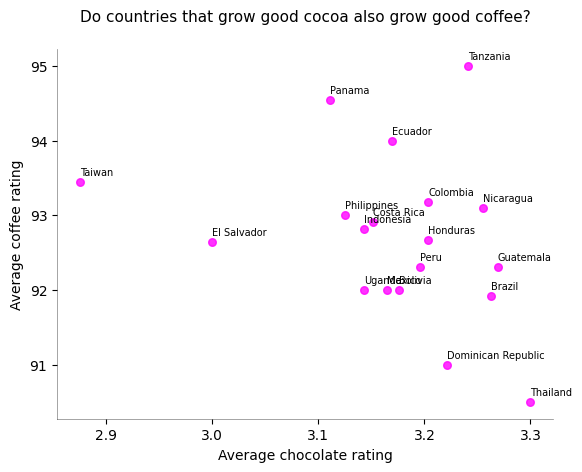

In [ ]:
# create the scatterplot
plt.scatter(
    merged['choc_avg'], 
    merged['coffee_avg'],
    color="magenta",
    alpha=.8,
    s = 30)

# modify spines
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_alpha(0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# label each point, requires a for loop: https://www.geeksforgeeks.org/python/how-to-annotate-matplotlib-scatter-plots/
x = [x for x in merged['choc_avg']]
y = [y for y in merged['coffee_avg']]
text = merged['origin']

for i in range(len(x)):
    plt.annotate(text[i], (x[i], y[i] + 0.09), fontsize=7)

# specify title and label axes
plt.xlabel('Average chocolate rating')
plt.ylabel('Average coffee rating')
plt.title('Do countries that grow good cocoa also grow good coffee?', fontsize=11, pad=20)

# I did not adjust the scale of axes. Doing so clustered the dots too closely together.
plt.show()

In [ ]:
conn.close()